Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
9406464/9406464 [==============================] - 4s 0us/step

--- Training Eksperimen 1 ---
Epoch 1/10
439/439 [==============================] - 344s 783ms/step - loss: 0.9910 - accuracy: 0.6295 - val_loss: 0.8277 - val_accuracy: 0.7147
Epoch 2/10
439/439 [==============================] - 200s 456ms/step - loss: 0.6967 - accuracy: 0.7450 - val_loss: 0.6800 - val_accuracy: 0.7513
Epoch 3/10
439/439 [==============================] - 202s 460ms/step - loss: 0.6125 - accuracy: 0.7774 - val_loss: 0.5920 - val_accuracy: 0.7907
Epoch 4/10
439/439 [==============================] - 194s 441ms/step - loss: 0.5412 - accuracy: 0.8032 - val_loss: 0.5493 - val_accuracy: 0.8080
Epoch 5/10
439/439 [==============================] - 192s 438ms/step - loss: 0.5066 - accuracy: 0.8159 - val_loss: 0.6320 - val_accuracy: 0.7823
Epoch 6/10
439/439 [=============================

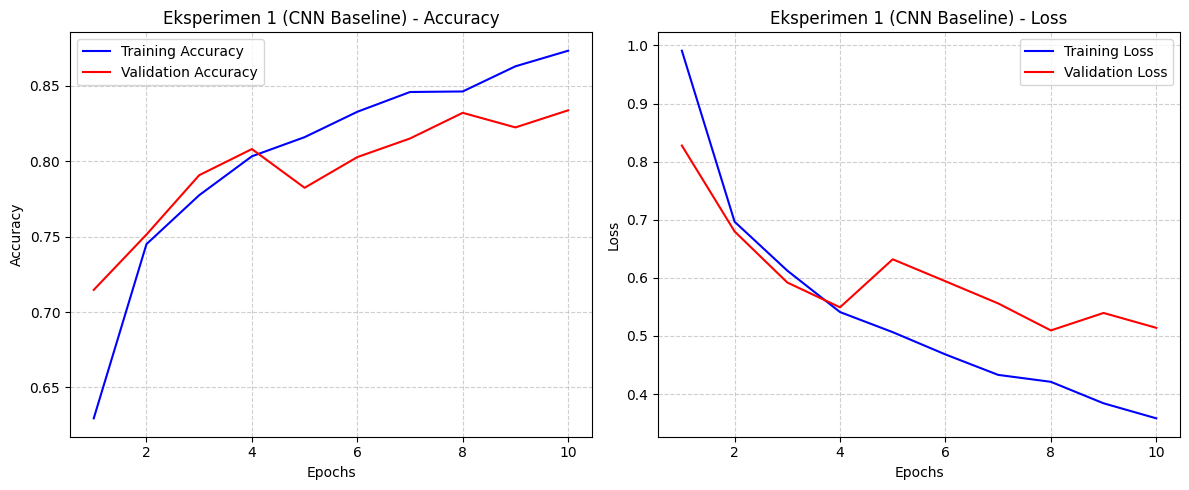


========== EVALUASI MODEL: Eksperimen 1 (CNN Baseline) ==========
94/94 [==============================] - 10s 103ms/step

--- Classification Report ---
              precision    recall  f1-score   support

   buildings       0.75      0.87      0.80       437
      forest       0.93      0.98      0.95       474
     glacier       0.82      0.79      0.81       553
    mountain       0.81      0.73      0.77       525
         sea       0.83      0.83      0.83       510
      street       0.87      0.83      0.85       501

    accuracy                           0.83      3000
   macro avg       0.83      0.84      0.83      3000
weighted avg       0.83      0.83      0.83      3000



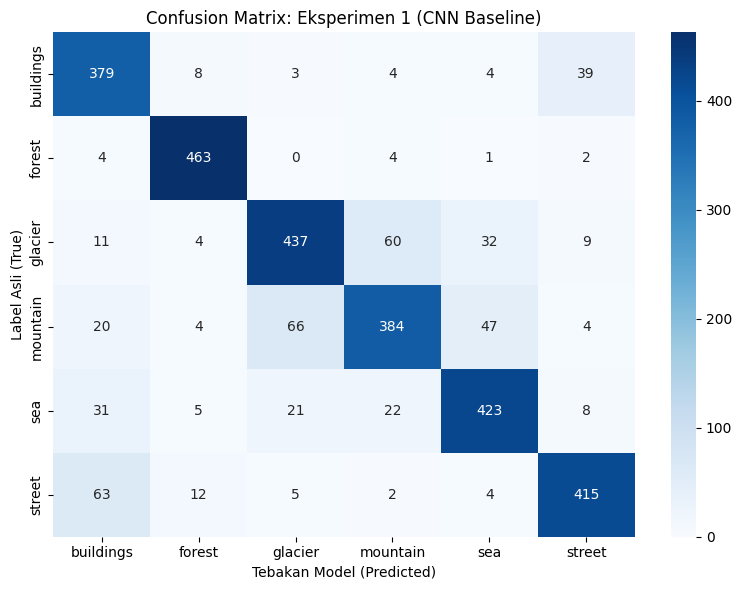

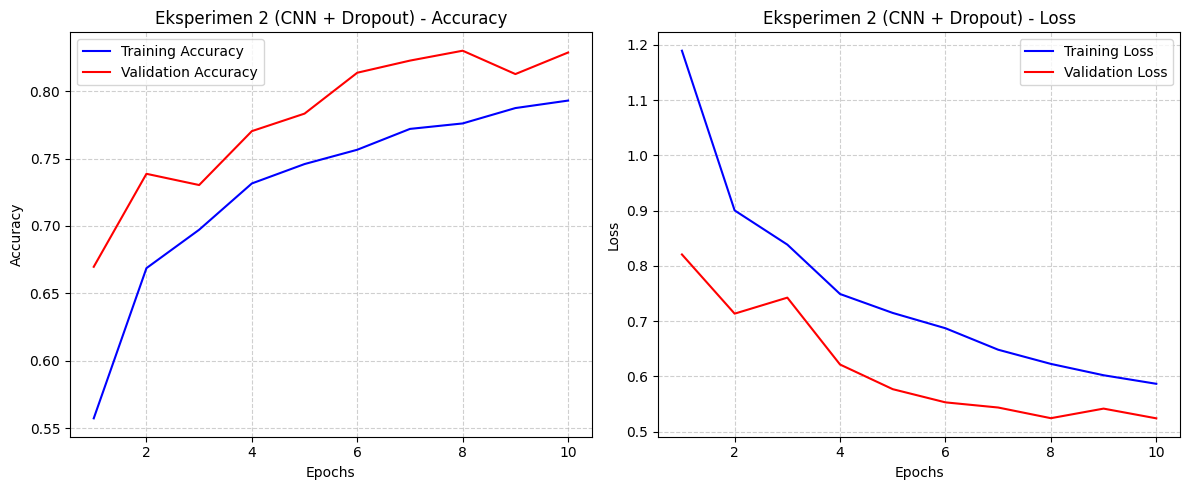


========== EVALUASI MODEL: Eksperimen 2 (CNN + Dropout) ==========
94/94 [==============================] - 10s 103ms/step

--- Classification Report ---
              precision    recall  f1-score   support

   buildings       0.82      0.83      0.82       437
      forest       0.92      0.98      0.95       474
     glacier       0.80      0.81      0.81       553
    mountain       0.87      0.63      0.73       525
         sea       0.74      0.85      0.79       510
      street       0.85      0.89      0.87       501

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



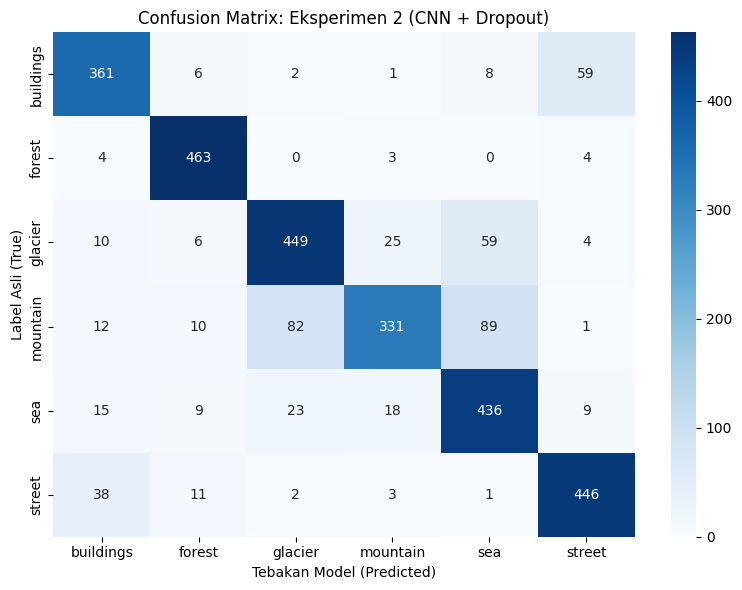

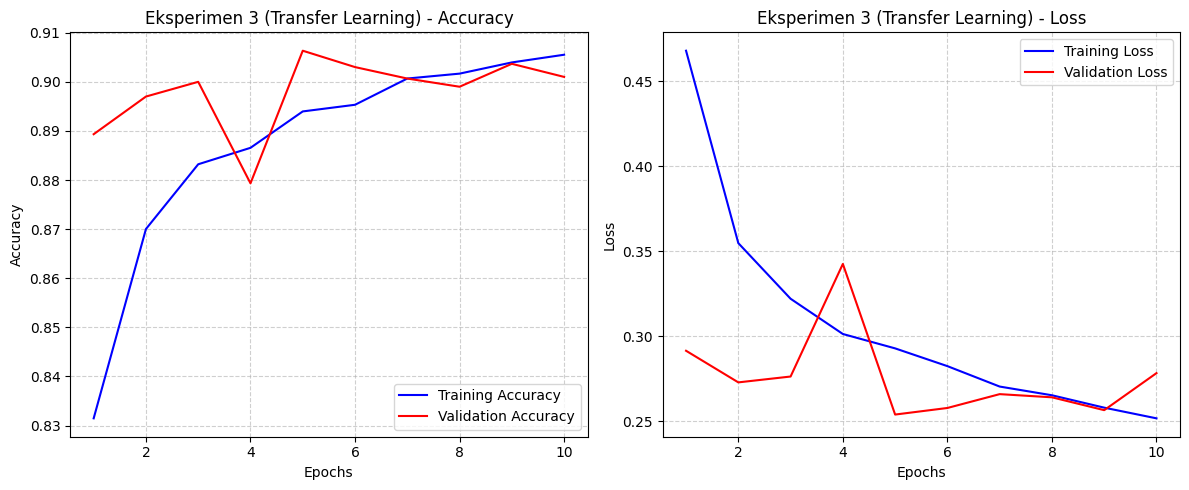


========== EVALUASI MODEL: Eksperimen 3 (Transfer Learning) ==========
94/94 [==============================] - 22s 226ms/step

--- Classification Report ---
              precision    recall  f1-score   support

   buildings       0.87      0.93      0.90       437
      forest       0.98      0.99      0.99       474
     glacier       0.91      0.78      0.84       553
    mountain       0.81      0.89      0.85       525
         sea       0.93      0.93      0.93       510
      street       0.92      0.90      0.91       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



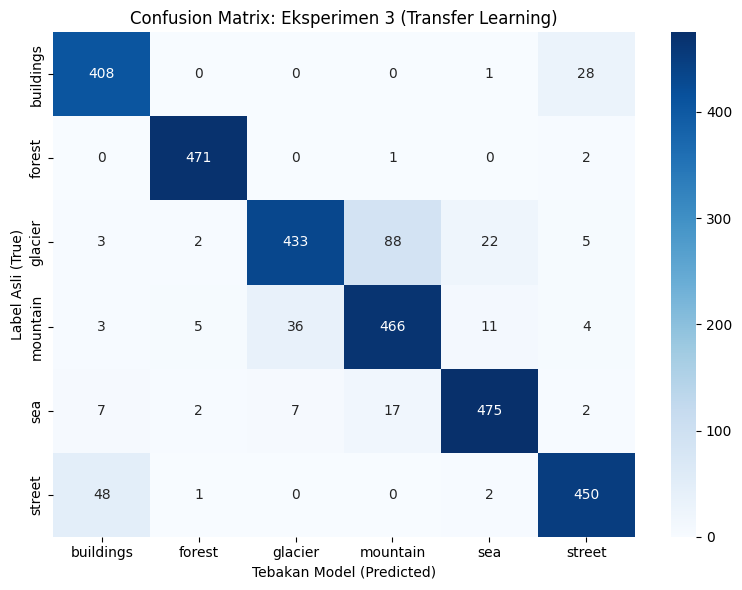

In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# 1. PARAMETER & JALUR DATASET (DISESUAIKAN DENGAN STRUKTUR FOLDER KAMU)
# ==============================================================================
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 6

TRAIN_DIR = 'intel_dataset/seg_train/seg_train'
VAL_DIR   = 'intel_dataset/seg_test/seg_test'
TEST_DIR  = 'intel_dataset/seg_test/seg_test'

# ==============================================================================
# 2. PREPROCESSING DATASET
# ==============================================================================
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# ==============================================================================
# 3. MEMBUAT ARSITEKTUR MODEL (E1, E2, E3)
# ==============================================================================
# Eksperimen 1: CNN Baseline
model_e1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Eksperimen 2: CNN + Dropout
model_e2 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Eksperimen 3: Transfer Learning (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False

model_e3 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# ==============================================================================
# 4. PROSES TRAINING (Menciptakan history_e1, history_e2, history_e3)
# ==============================================================================
EPOCHS = 10

print("\n--- Training Eksperimen 1 ---")
model_e1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_e1 = model_e1.fit(train_generator, epochs=EPOCHS, validation_data=val_generator)

print("\n--- Training Eksperimen 2 ---")
model_e2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_e2 = model_e2.fit(train_generator, epochs=EPOCHS, validation_data=val_generator)

print("\n--- Training Eksperimen 3 ---")
model_e3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_e3 = model_e3.fit(train_generator, epochs=EPOCHS, validation_data=val_generator)

# ==============================================================================
# 5. FUNGSI VISUALISASI & EVALUASI
# ==============================================================================
def plot_history(history, title, save_name=None):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    
    # Grafik Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Grafik Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    if save_name:
        plt.savefig(f"{save_name}_history.png", dpi=300)
    plt.show()

def evaluate_model(model, test_gen, title, save_name=None):
    print(f"\n========== EVALUASI MODEL: {title} ==========")
    test_gen.reset()
    
    Y_pred = model.predict(test_gen, steps=len(test_gen), verbose=1)
    y_pred_classes = np.argmax(Y_pred, axis=1)
    y_true = test_gen.classes
    
    class_names = list(test_gen.class_indices.keys())
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred_classes, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Label Asli (True)')
    plt.xlabel('Tebakan Model (Predicted)')
    plt.tight_layout()
    if save_name:
        plt.savefig(f"{save_name}_cm.png", dpi=300)
    plt.show()

# ==============================================================================
# 6. EKSEKUSI VISUALISASI
# ==============================================================================
plot_history(history_e1, "Eksperimen 1 (CNN Baseline)", save_name="e1")
evaluate_model(model_e1, test_generator, "Eksperimen 1 (CNN Baseline)", save_name="e1")

plot_history(history_e2, "Eksperimen 2 (CNN + Dropout)", save_name="e2")
evaluate_model(model_e2, test_generator, "Eksperimen 2 (CNN + Dropout)", save_name="e2")

plot_history(history_e3, "Eksperimen 3 (Transfer Learning)", save_name="e3")
evaluate_model(model_e3, test_generator, "Eksperimen 3 (Transfer Learning)", save_name="e3")